# Goal: Analyse if there is any correlation between the proportion of UTD labels on the whole project and the f1-scores obtained for all the projects

In [1]:
from pathlib import Path

def find_file(folder_path, prefix):
    # folder.glob('prefix*') looks for anything starting with the prefix
    folder = Path(folder_path)
    try:
        return next(folder.glob(f"{prefix}*"))
    except StopIteration:
        return None  # No file found

In [8]:
import pandas as pd
from tqdm import tqdm
import re

MODELS = ["LightGBM", "LogisticRegression", "RF", "XGB"]
# MODELS = ["LightGBM"]
# MODELS = ["LogisticRegression"]
GRANULARITIES = ['file', 'class', 'method', 'block']
PROJECTS = ['ANTLR4', 'DBeaver', 'Elasticsearch', 'ExoPlayer', 'FastJSON', 'Flink', 'Guava', 'Jenkins', 'LibGDX', 'Logstash', 'Mockito', 'OpenRefine', 'Presto', 'Quarkus', 'QuestDB', 'Redisson', 'RxJava', 'Tink']
DF_FOLDER_PATH = "../../code snippets-with-labels&metrics"

CONTRIBUTORS_COUNT  = {
    # 'ANTLR4': 363,
    'DBeaver': 441,
    'Elasticsearch': 2184, 
    'ExoPlayer': 233, 
    'FastJSON': 175, 
    'Flink': 1372, 
    'Guava': 327, 
    'Jenkins': 848, 
    # 'LibGDX': 577, 
    # 'Logstash': 463, 
    'Mockito': 312,
    'OpenRefine': 413, # this OpenRefine is 68%...
    'Presto': 872, 
    'Quarkus': 1220, 
    'QuestDB': 180, 
    'Redisson': 219, 
    'RxJava': 296, 
    # 'Tink': 111

    'ANTLR4': -1,
    'LibGDX': -1,
    'Logstash': -1,
    'Tink': -1

}

project_utd_proportion_dict_by_granularity = {}
total_utd = 0
total_code_snippets = 0
for granularity in tqdm(GRANULARITIES):
    project_utd_proportion_dict_by_granularity[granularity] = {}
    granularity_counts = project_utd_proportion_dict_by_granularity[granularity]

    for project in PROJECTS:
        all_projects_folder_path = f"{DF_FOLDER_PATH}/{granularity}/"
        project_file = find_file(folder_path=all_projects_folder_path, prefix=project.lower())
        
        project_df = pd.read_csv(project_file)
        utd_count = (pd.read_csv(project_file)["CommentsAssociatedLabel"] == 1).sum()
        code_snippet_count = project_df.shape[0]

        # granularity_counts[project] = utd_count / code_snippet_count
        granularity_counts[project] = CONTRIBUTORS_COUNT[project]

        total_utd += utd_count
        total_code_snippets += code_snippet_count

total_utd, total_code_snippets, total_utd/total_code_snippets

100%|██████████| 4/4 [00:27<00:00,  6.98s/it]


(np.int64(22999), 364932, np.float64(0.0630227001194743))

In [9]:
DATA_FOLDER_PATH = '../results/trying_other_models/'
RESULTS_PREFIX = 'within_project_ASMOTE_'



METRICS = ["Precison", "Recall", "F1-Score", "AUC", "MCC"]
METRIC_IDX = 2
METRIC_NAME = METRICS[METRIC_IDX]

GRANULARITY_TO_IDX_IN_TABLE_ROW = {
    "file": METRIC_IDX + 1,
    "class": METRIC_IDX + 1 + 5 * 1,
    "method": METRIC_IDX + 1 + 5 * 2,
    "block": METRIC_IDX + 1 + 5 * 3
}

results_dict = {}
for model in MODELS:
    results_dict[model] = {}
    model_results = results_dict[model]

    FILE_PATH = DATA_FOLDER_PATH + RESULTS_PREFIX + model + ".txt"
    with open(FILE_PATH, "r") as file:
        scores_by_project = file.read().split("\n")[0:-2]

        for granularity in GRANULARITIES:
            model_results[granularity] = {}
            granularity_results = model_results[granularity]

            for project_scores in scores_by_project:
                project_scores = project_scores.split("&")

                project = project_scores[0].strip()
                idx = GRANULARITY_TO_IDX_IN_TABLE_ROW[granularity]
                granularity_results[project] = project_scores[idx] 

                # print(type(granularity_results[project]))
                if "%" not in granularity_results[project]:
                    granularity_results[project] = str(float(granularity_results[project].replace("\\", "")) * 100) + "\%"     
                # print(granularity_results[project])

PROJECTS = list(results_dict["LightGBM"]["block"].keys())

<>:39: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
<>:39: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
/tmp/ipykernel_56518/2074659523.py:39: SyntaxWarning: "\%" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\%"? A raw string is also an option.
  granularity_results[project] = str(float(granularity_results[project].replace("\\", "")) * 100) + "\%"


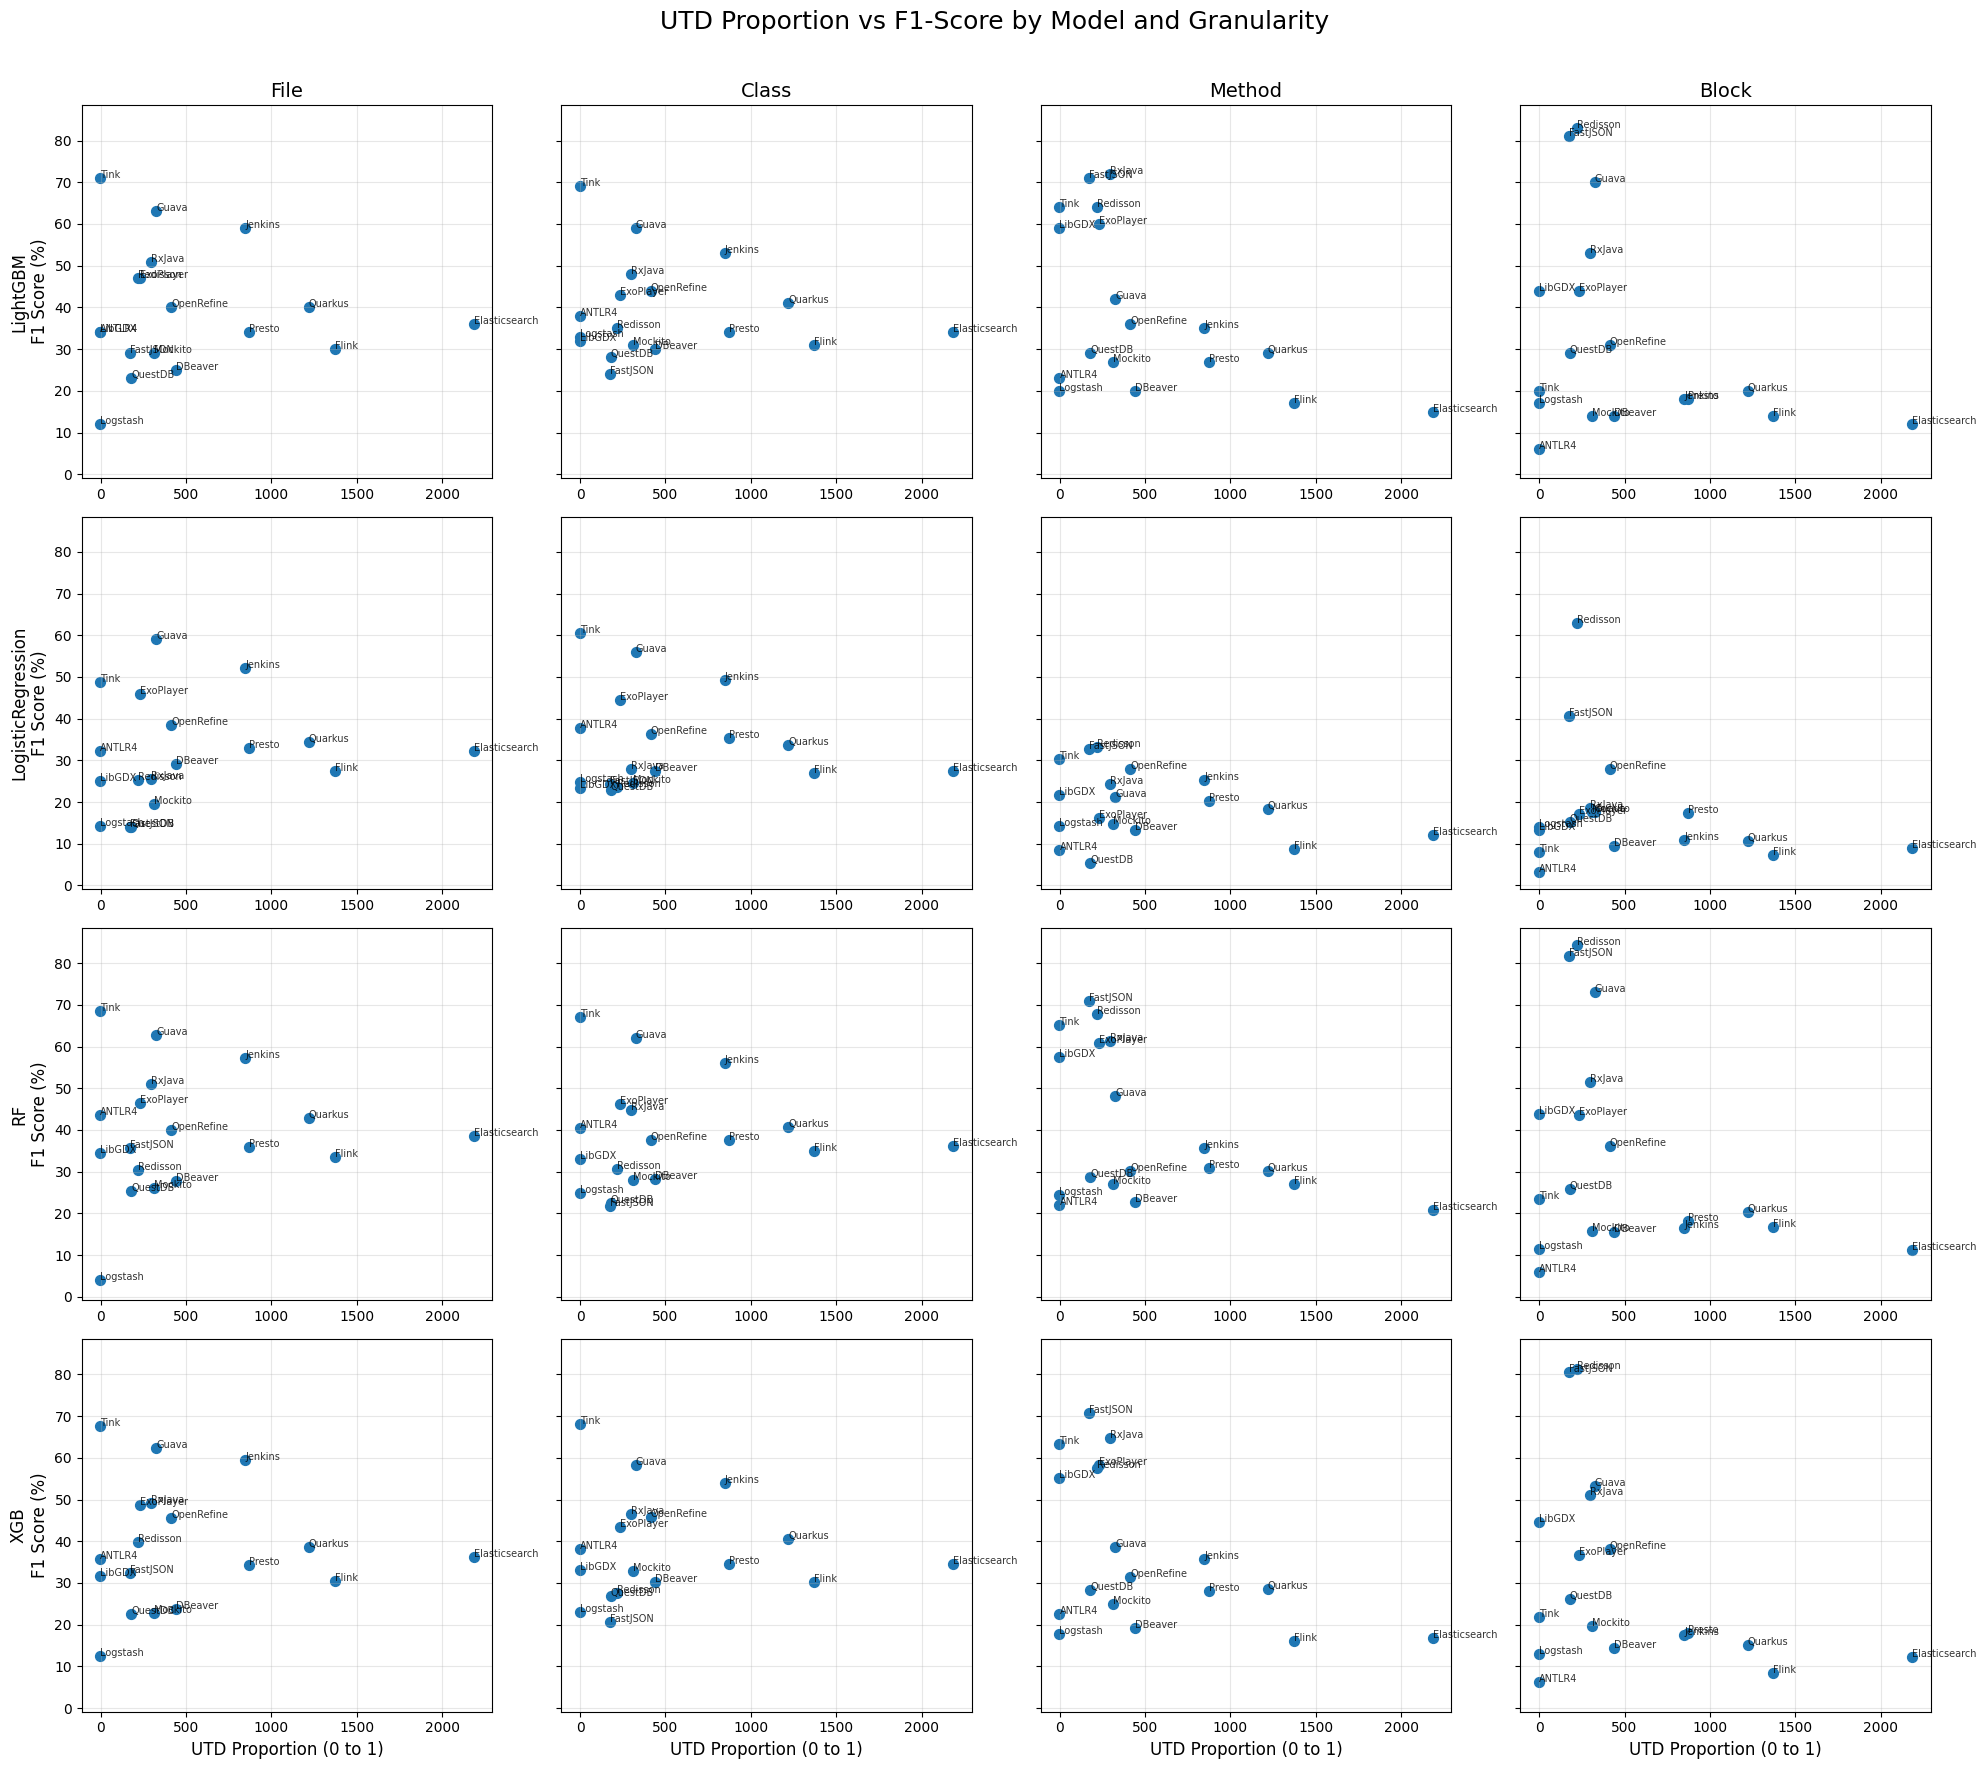

In [10]:
import matplotlib.pyplot as plt
import re

# Order of rows and columns
models = ["LightGBM", "LogisticRegression", "RF", "XGB"]
granularities = ["file", "class", "method", "block"]

# Function to convert LaTeX percentage strings to floats
def parse_percent(s):
    s = s.replace("\\enspace", "")
    s = s.replace("\\%", "")
    return float(re.sub(r"\s+", "", s))

fig, axes = plt.subplots(
    nrows=len(models),
    ncols=len(granularities),
    figsize=(20, 18),
    sharex=False,
    sharey=True
)

for i, model in enumerate(models):
    for j, granularity in enumerate(granularities):

        ax = axes[i, j]

        counts_dict = project_utd_proportion_dict_by_granularity[granularity]
        scores_dict = results_dict[model][granularity]

        # Keep projects in the same order
        projects = list(counts_dict.keys())

        x = [counts_dict[p] for p in projects]
        y = [parse_percent(scores_dict[p]) for p in projects]

        ax.scatter(x, y, s=50)

        # Optional: label each point
        for xx, yy, project in zip(x, y, projects):
            ax.annotate(
                project,
                (xx, yy),
                fontsize=7,
                alpha=0.8
            )

        if i == 0:
            ax.set_title(granularity.capitalize(), fontsize=14)

        if j == 0:
            ax.set_ylabel(f"{model}\nF1 Score (%)", fontsize=12)

        if i == len(models) - 1:
            ax.set_xlabel("UTD Proportion (0 to 1)", fontsize=12)

        ax.grid(alpha=0.3)

fig.suptitle(f"UTD Proportion vs {METRIC_NAME} by Model and Granularity", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()